In [1]:
import matplotlib.pyplot as plt
import scienceplots
import pandas as pd
import glob
import os

plt.style.use(['science'])

pra_params = {
    'font.size': 12,
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Computer Modern Roman'],
}

plt.rcParams.update(pra_params)

In [2]:
file_paths = glob.glob('*.csv')
data_dict = {}

for path in file_paths:
    file_name = os.path.basename(path)
    label = os.path.splitext(file_name)[0]
    data_dict[label] = pd.read_csv(path)

In [3]:
d_lst = data_dict['atom_based_p_l_0_5']['distance_km'].to_numpy()

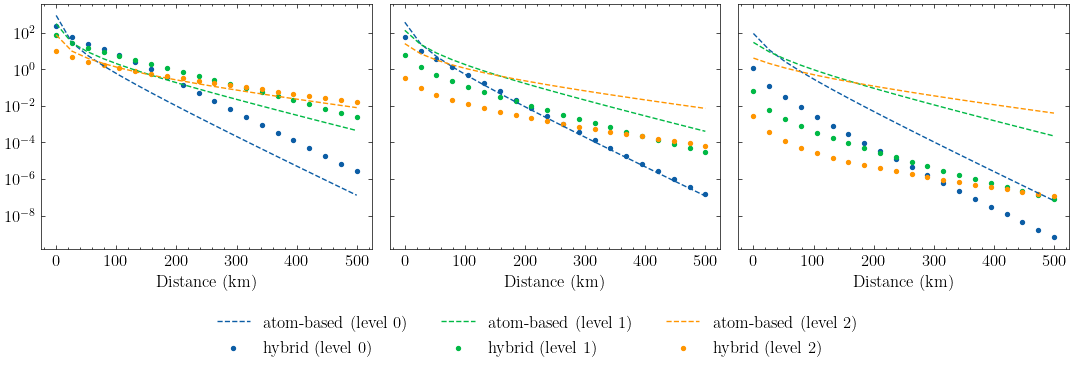

In [4]:
# Parameter sets for the 3 subplots
configs = [
    {'tag': '0_01', 'title': r'$p_l = 0.01$'},
    {'tag': '0_1',  'title': r'$p_l = 0.1$'},
    {'tag': '0_5',  'title': r'$p_l = 0.5$'},
]

levels = [0, 1, 2]
colors = ['C0', 'C1', 'C2']

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5), sharey=True)

for ax, cfg in zip(axes, configs):
    tag = cfg['tag']
    atom_df = data_dict[f'atom_based_p_l_{tag}']
    hybrid_df = data_dict[f'hybrid_p_l_{tag}']

    for lvl, c in zip(levels, colors):
        ax.plot(
            d_lst,
            atom_df[f'keyrate_bps_level_{lvl}'].to_numpy(),
            label=f'atom-based (level {lvl})',
            linestyle='--',
            color=c,
        )
        ax.scatter(
            d_lst,
            hybrid_df[f'keyrate_bps_level_{lvl}'].to_numpy(),
            label=f'hybrid (level {lvl})',
            color=c,
            s=8,
        )

    ax.set_yscale('log')
    ax.set_xlabel(r'Distance (km)')
    # ax.set_title(cfg['title'])

# Extract handles and labels from the first axis
handles, labels = axes[0].get_legend_handles_labels()

# Place the shared 2-row legend below the plots
fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
    frameon=False,
)

# Use bbox_inches='tight' when saving or adjust rect in tight_layout so it doesn't get clipped
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('rate.pdf')
plt.show()
